In [2]:
import pandas as pd
import numpy as np

In [5]:
raw = pd.read_csv("../data/raw/ai4i2020.csv")

In [11]:
raw.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [12]:
raw.shape

(10000, 14)

In [14]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [15]:
raw.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [16]:
raw.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [17]:
raw.duplicated().sum()

np.int64(0)

In [18]:
raw["Type"].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [20]:
raw["Product ID"].nunique()

10000

In [21]:
raw["Product ID"].head(20)

0     M14860
1     L47181
2     L47182
3     L47183
4     L47184
5     M14865
6     L47186
7     L47187
8     M14868
9     M14869
10    H29424
11    H29425
12    M14872
13    M14873
14    L47194
15    L47195
16    M14876
17    M14877
18    H29432
19    M14879
Name: Product ID, dtype: object

In [22]:
raw["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [23]:
raw["Machine failure"].value_counts(normalize=True) * 100

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

In [26]:
raw[["TWF", "HDF", "PWF", "OSF", "RNF"]].sum()

TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64

In [27]:
raw[["TWF", "HDF", "PWF", "OSF", "RNF"]].value_counts()

TWF  HDF  PWF  OSF  RNF
0    0    0    0    0      9652
     1    0    0    0       106
     0    1    0    0        80
          0    1    0        78
1    0    0    0    0        42
0    0    0    0    1        18
          1    1    0        11
     1    0    1    0         6
          1    0    0         3
1    0    0    1    0         2
               0    1         1
          1    1    0         1
Name: count, dtype: int64

In [ ]:
pd.crosstab(
    raw["Type"], 
    raw["Machine failure"], 
    normalize="index"
) * 100

Machine failure,0,1
Type,,
H,97.906281,2.093719
L,96.083333,3.916667
M,97.230564,2.769436


In [30]:
failure_modes = ["TWF", "HDF", "PWF", "OSF", "RNF"]

for col in failure_modes:
    print(f"\n{col}")
    print(pd.crosstab(raw[col], raw["Machine failure"]))


TWF
Machine failure     0    1
TWF                       
0                9661  293
1                   0   46

HDF
Machine failure     0    1
HDF                       
0                9661  224
1                   0  115

PWF
Machine failure     0    1
PWF                       
0                9661  244
1                   0   95

OSF
Machine failure     0    1
OSF                       
0                9661  241
1                   0   98

RNF
Machine failure     0    1
RNF                       
0                9643  338
1                  18    1


In [31]:
sensor_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

raw.groupby("Machine failure")[sensor_features].mean()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Machine failure,,,,,
0,299.973999,309.995570,1540.260014,39.629655,106.693717
1,300.886431,310.290265,1496.486726,50.168142,143.781711


In [32]:
raw.groupby("Machine failure")[sensor_features].median()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Machine failure,,,,,
0,300.0,310.0,1507.0,39.9,107.0
1,301.6,310.4,1365.0,53.7,165.0


In [33]:
raw.groupby("Machine failure")[sensor_features].agg(["mean", "median", "std"])

Air temperature [K]                  Process temperature [K]  \
                               mean median       std                    mean   
Machine failure                                                                
0                        299.973999  300.0  1.990748              309.995570   
1                        300.886431  301.6  2.071473              310.290265   

                                 Rotational speed [rpm]                      \
                median       std                   mean  median         std   
Machine failure                                                               
0                310.0  1.486846            1540.260014  1507.0  167.394734   
1                310.4  1.363686            1496.486726  1365.0  384.943547   

                Torque [Nm]                   Tool wear [min]         \
                       mean median        std            mean median   
Machine failure                                                        
0                 39.629655   39.9   9.472080      106.693717  107.0   
1                 50.168142   53.7  16.374498      143.781711  165.0   

                            
                       std  
Machine failure             
0                62.945790  
1                72.759876

In [34]:
type_failure = pd.crosstab(
    raw["Type"],
    raw["Machine failure"]
)

type_failure

Machine failure,0,1
Type,,
H,982,21
L,5765,235
M,2914,83


In [35]:
type_failure["Failure Rate (%)"] = (
    type_failure[1] /
    type_failure.sum(axis=1)
) * 100

type_failure

Machine failure,0,1,Failure Rate (%)
Type,,,
H,982,21,2.093719
L,5765,235,3.916667
M,2914,83,2.769436


<Axes: title={'center': 'Machine Failure Distribution'}, xlabel='Machine failure'>

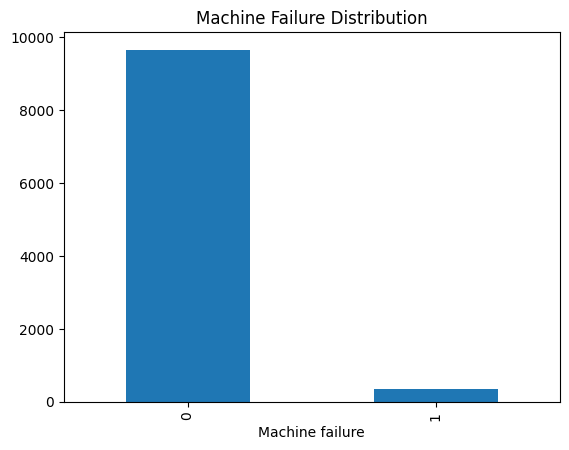

In [36]:
raw["Machine failure"].value_counts().plot(
    kind="bar",
    title="Machine Failure Distribution"
)

array([[<Axes: title={'center': 'Air temperature [K]'}>,
        <Axes: title={'center': 'Process temperature [K]'}>],
       [<Axes: title={'center': 'Rotational speed [rpm]'}>,
        <Axes: title={'center': 'Torque [Nm]'}>],
       [<Axes: title={'center': 'Tool wear [min]'}>, <Axes: >]],
      dtype=object)

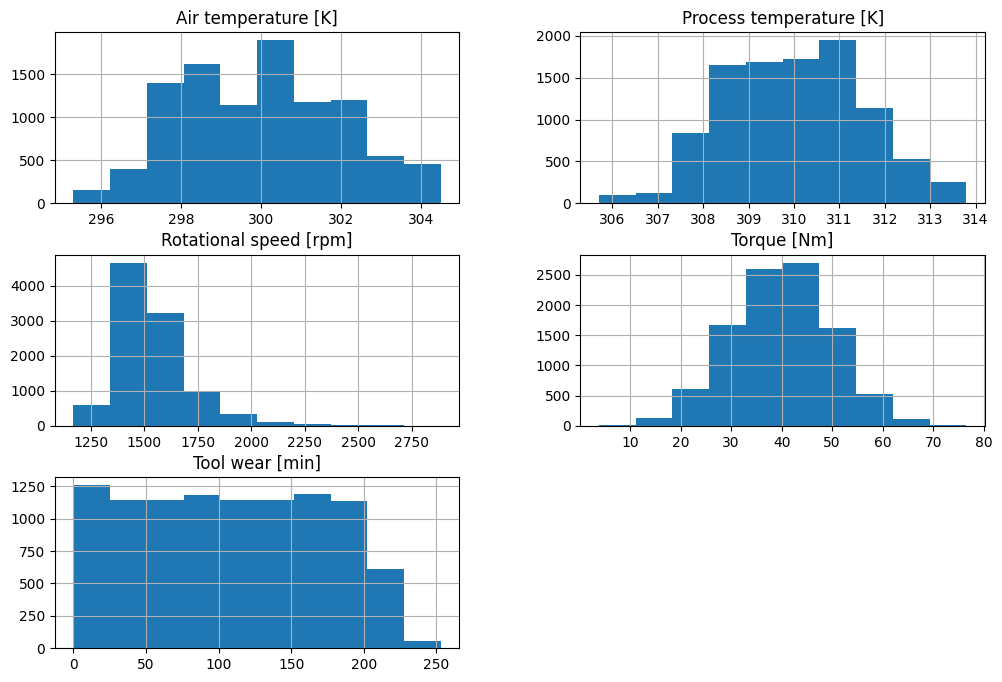

In [37]:
raw[sensor_features].hist(
    figsize=(12, 8)
)

<Figure size 800x500 with 0 Axes>

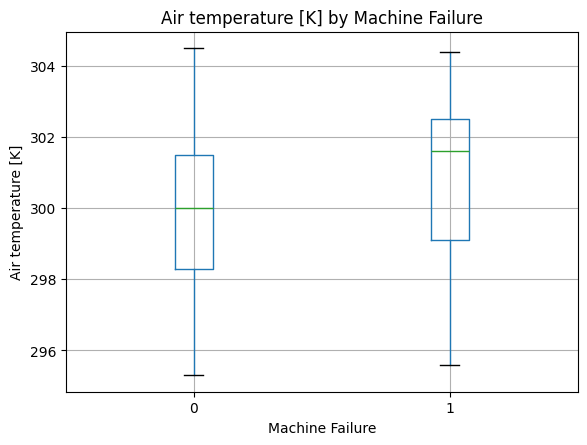

<Figure size 800x500 with 0 Axes>

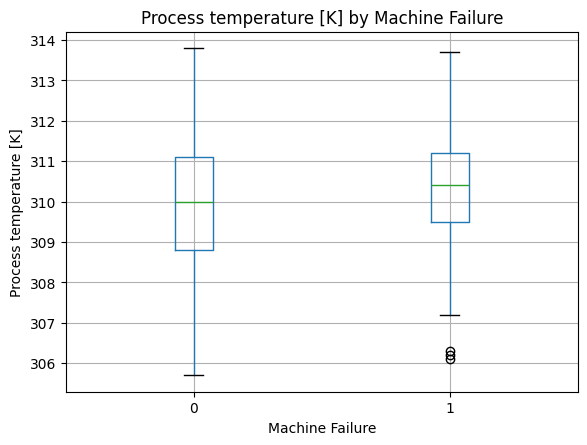

<Figure size 800x500 with 0 Axes>

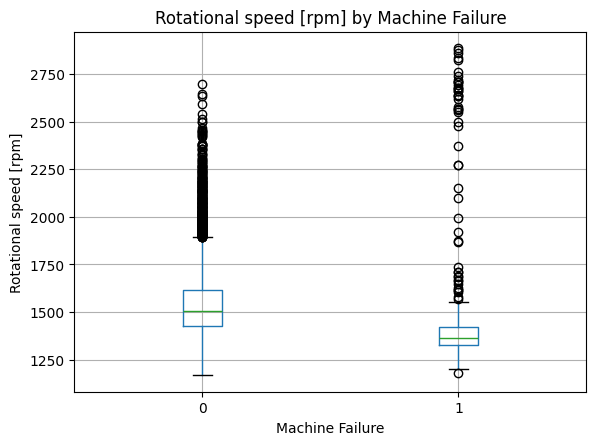

<Figure size 800x500 with 0 Axes>

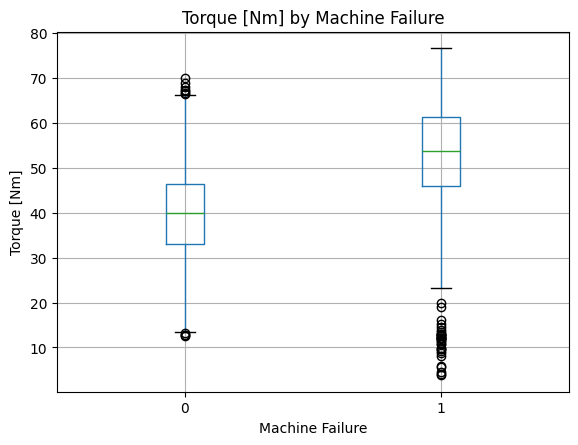

<Figure size 800x500 with 0 Axes>

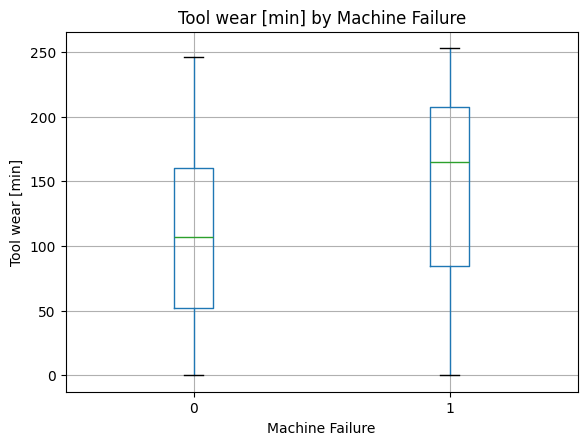

In [38]:
import matplotlib.pyplot as plt

for feature in sensor_features:
    plt.figure(figsize=(8, 5))

    raw.boxplot(
        column=feature,
        by="Machine failure"
    )

    plt.title(f"{feature} by Machine Failure")
    plt.suptitle("")
    plt.xlabel("Machine Failure")
    plt.ylabel(feature)

    plt.show()
    

In [39]:
raw.groupby("Machine failure")[sensor_features].mean().T

Machine failure,0,1
Air temperature [K],299.973999,300.886431
Process temperature [K],309.995570,310.290265
Rotational speed [rpm],1540.260014,1496.486726
Torque [Nm],39.629655,50.168142
Tool wear [min],106.693717,143.781711


In [40]:
raw.groupby("Machine failure")[sensor_features].median().T

Machine failure,0,1
Air temperature [K],300.0,301.6
Process temperature [K],310.0,310.4
Rotational speed [rpm],1507.0,1365.0
Torque [Nm],39.9,53.7
Tool wear [min],107.0,165.0


In [41]:
corr_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Machine failure"
]

corr = raw[corr_features].corr()

corr

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
Air temperature [K],1.000000,0.876107,0.022670,-0.013778,0.013853,0.082556
Process temperature [K],0.876107,1.000000,0.019277,-0.014061,0.013488,0.035946
Rotational speed [rpm],0.022670,0.019277,1.000000,-0.875027,0.000223,-0.044188
Torque [Nm],-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.191321
Tool wear [min],0.013853,0.013488,0.000223,-0.003093,1.000000,0.105448
Machine failure,0.082556,0.035946,-0.044188,0.191321,0.105448,1.000000


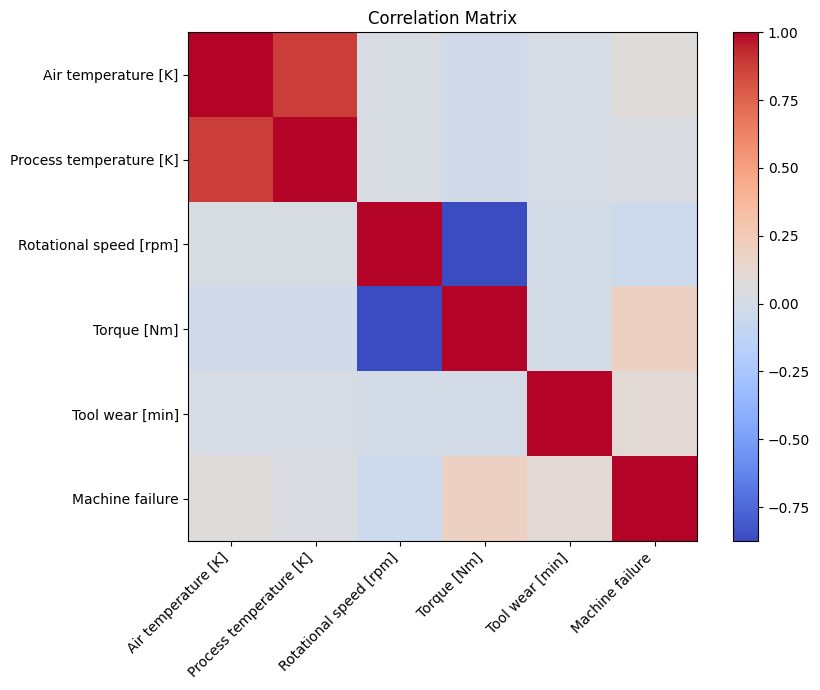

In [42]:
plt.figure(figsize=(9, 7))

plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

## EDA Conclusions

The exploratory data analysis was performed to understand the dataset structure, target distribution, sensor behavior, and relationships between the available features and machine failure.

### Key Findings

- The dataset contains both numerical sensor measurements and categorical machine information.
- The target variable, `Machine failure`, is highly imbalanced, with significantly more non-failure observations than failure observations. This class imbalance will need to be considered during model development.
- The failure rate varies across machine types, indicating that `Type` may provide useful information for predicting machine failure.
- Failed machines generally show:
  - Higher **air temperature**
  - Slightly higher **process temperature**
  - Lower **rotational speed**
  - Higher **torque**
  - Higher **tool wear**
- Among the numerical features, **Torque** has the highest positive correlation with machine failure (`0.1913`), followed by **Tool wear** (`0.1054`).
- Air temperature (`0.0826`), process temperature (`0.0359`), and rotational speed (`-0.0442`) have relatively weak linear correlations with machine failure.
- Strong correlations exist between some sensor variables:
  - Air temperature and process temperature: `0.8761`
  - Rotational speed and torque: `-0.8750`
- These strong feature-to-feature correlations indicate that some sensor measurements contain overlapping information.
- The distributions and boxplots also show differences between failed and non-failed observations, particularly for rotational speed, torque, and tool wear.

### Conclusion

The EDA indicates that machine failure is influenced by multiple sensor characteristics rather than a single variable. Although individual linear correlations with the target are relatively weak, the differences observed between failure and non-failure groups suggest that the features may collectively provide useful predictive information.

All relevant features will initially be retained for model development. Feature importance and model performance will be used later to determine which variables contribute most to failure prediction.

### Next Step

The next stage of the project is **data preprocessing**, including feature preparation, categorical encoding, train-test splitting, and handling the class imbalance before model training.